# 05b — Advanced Methods for Turbidity Estimation

This notebook explores methods that can potentially outperform the baseline approaches in 05_dimensionality_reduction:

1. **Stronger models**: XGBoost, LightGBM, ElasticNet, Stacking
2. **Sparse methods**: Sparse PCA, Dictionary Learning
3. **Nonlinear manifold**: t-SNE (visualisation only), PHATE
4. **Feature selection**: Mutual Information, Lasso-based, Stability Selection
5. **Cross-validation**: Leave-One-Group-Out (LOGO) for robust evaluation
6. **Target transformation**: log-turbidity for better scaling

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.base import clone
from sklearn.decomposition import SparsePCA, DictionaryLearning, NMF
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.feature_selection import mutual_info_regression, SelectFromModel
from sklearn.linear_model import Ridge, ElasticNet, LassoCV, BayesianRidge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.svm import SVR

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

warnings.filterwarnings("ignore")

# ── Load datasets ────────────────────────────────────────────────────────
FE_DIR    = Path("../data/processed/feature_engineering")
META_COLS = ["ctd", "date", "turbidity"]

datasets = {}
for f in sorted(FE_DIR.glob("*.parquet")):
    df = pd.read_parquet(f)
    df["date"] = pd.to_datetime(df["date"]).dt.date
    df["ctd"]  = df["ctd"].astype(str)
    df["turbidity"] = pd.to_numeric(df["turbidity"], errors="coerce")
    df = df.dropna(subset=["turbidity"])
    datasets[f.stem] = df

print(f"Loaded {len(datasets)} datasets")
for name, df in datasets.items():
    feat_cols = [c for c in df.columns if c not in META_COLS]
    print(f"  {name:40s}  N={len(df):4d}  features={len(feat_cols)}")

In [ ]:
def get_Xy(df, log_transform=False):
    """Split a feature dataset into X (scaled), y, and groups (ctd)."""
    feat_cols = [c for c in df.columns if c not in META_COLS]
    X_raw = df[feat_cols].values.astype(np.float32)
    y     = df["turbidity"].values.astype(np.float32)
    groups = df["ctd"].values
    # Drop columns that are entirely NaN, then impute remaining NaN with column mean
    col_mask = ~np.all(np.isnan(X_raw), axis=0)
    X_raw    = X_raw[:, col_mask]
    col_means = np.nanmean(X_raw, axis=0)
    nan_mask  = np.isnan(X_raw)
    X_raw[nan_mask] = np.take(col_means, np.where(nan_mask)[1])
    scaler = StandardScaler()
    X      = scaler.fit_transform(X_raw)
    if log_transform:
        y = np.log1p(y)
    return X, y, groups, [feat_cols[i] for i in range(len(feat_cols)) if col_mask[i]]


def cv_scores(X, y, groups, model, n_splits=5, log_transform=False):
    """Return mean RMSE, CV_RMSE, MAE, R² over GroupKFold splits."""
    n_groups = len(np.unique(groups))
    if n_groups <= 2:
        # Use LOGO if very few groups
        gkf = LeaveOneGroupOut()
        splits = list(gkf.split(X, y, groups))
    else:
        gkf = GroupKFold(n_splits=min(n_splits, n_groups))
        splits = list(gkf.split(X, y, groups))

    rmse_list, cv_rmse_list, mae_list, r2_list = [], [], [], []
    for tr, te in splits:
        model_clone = clone(model)
        model_clone.fit(X[tr], y[tr])
        pred = model_clone.predict(X[te])
        # Undo log transform for metrics
        if log_transform:
            pred_orig = np.expm1(pred)
            y_orig    = np.expm1(y[te])
        else:
            pred_orig = pred
            y_orig    = y[te]
        mse = mean_squared_error(y_orig, pred_orig)
        rmse = np.sqrt(mse)
        y_test_mean = np.mean(y_orig)
        cv_rmse = rmse / y_test_mean if y_test_mean > 0 else np.nan
        rmse_list.append(rmse)
        cv_rmse_list.append(cv_rmse)
        mae_list.append(mean_absolute_error(y_orig, pred_orig))
        r2_list.append(r2_score(y_orig, pred_orig))
    return np.mean(rmse_list), np.mean(cv_rmse_list), np.mean(mae_list), np.mean(r2_list)


MODELS_ADV = {
    "Ridge":        Ridge(alpha=1.0),
    "ElasticNet":   ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=5000),
    "BayesianRidge": BayesianRidge(),
    "SVR_rbf":      SVR(kernel="rbf", C=1.0, epsilon=0.1),
    "KNN":          KNeighborsRegressor(n_neighbors=3),
    "RF":           RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

if HAS_XGB:
    MODELS_ADV["XGBoost"] = xgb.XGBRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.1,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1
    )

if HAS_LGBM:
    MODELS_ADV["LightGBM"] = lgb.LGBMRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.1,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1,
        verbose=-1
    )

all_results = []
print(f"Models: {list(MODELS_ADV.keys())}")

## 1. Baseline with Expanded Model Set

Test stronger models on the best-performing datasets from notebook 05.

In [3]:
TEST_DATASETS = ["fe_tabular", "fe_64px_texture", "fe_64px_stats"]

for ds_name in TEST_DATASETS:
    if ds_name not in datasets:
        continue
    X, y, groups, _ = get_Xy(datasets[ds_name])
    print(f"\n{ds_name}  ({X.shape[1]} features, N={len(y)})")
    for model_name, model in MODELS_ADV.items():
        rmse, cv_rmse, mae, r2 = cv_scores(X, y, groups, clone(model))
        print(f"  {model_name:15s}  RMSE={rmse:.4f}  CV_RMSE={cv_rmse:.4f}  MAE={mae:.4f}  R\u00b2={r2:.4f}")
        all_results.append({
            "method": "Baseline", "dataset": ds_name, "model": model_name,
            "n_components": X.shape[1],
            "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": mae, "R2": r2,
        })


fe_tabular  (45 features, N=419)
  Ridge            RMSE=1.1937  CV_RMSE=0.8800  MAE=0.7006  R²=0.0589
  ElasticNet       RMSE=1.2071  CV_RMSE=0.8887  MAE=0.7222  R²=0.0399
  BayesianRidge    RMSE=1.2061  CV_RMSE=0.8877  MAE=0.7167  R²=0.0420
  SVR_rbf          RMSE=1.2177  CV_RMSE=0.8951  MAE=0.6661  R²=0.0253
  KNN              RMSE=1.1426  CV_RMSE=0.8449  MAE=0.6908  R²=0.1261
  RF               RMSE=1.0615  CV_RMSE=0.7887  MAE=0.6421  R²=0.2375

fe_64px_texture  (69 features, N=415)
  Ridge            RMSE=1.2096  CV_RMSE=0.8689  MAE=0.7321  R²=0.0083
  ElasticNet       RMSE=1.2022  CV_RMSE=0.8622  MAE=0.7197  R²=0.0274
  BayesianRidge    RMSE=1.2021  CV_RMSE=0.8621  MAE=0.7184  R²=0.0282
  SVR_rbf          RMSE=1.2056  CV_RMSE=0.8610  MAE=0.6582  R²=0.0346
  KNN              RMSE=1.1186  CV_RMSE=0.8033  MAE=0.7169  R²=0.1496
  RF               RMSE=1.1455  CV_RMSE=0.8245  MAE=0.7064  R²=0.1048

fe_64px_stats  (45 features, N=415)
  Ridge            RMSE=1.1948  CV_RMSE=0.8553  MA

## 2. Log-Transformed Target

Turbidity is positive and skewed. Log-transforming can help linear models and reduce the impact of outliers.

In [4]:
LOG_MODELS = {"Ridge", "ElasticNet", "BayesianRidge", "SVR_rbf"}

for ds_name in TEST_DATASETS:
    if ds_name not in datasets:
        continue
    X, y_log, groups, _ = get_Xy(datasets[ds_name], log_transform=True)
    print(f"\n{ds_name}  (log-transformed target)")
    for model_name, model in MODELS_ADV.items():
        if model_name not in LOG_MODELS:
            continue
        rmse, cv_rmse, mae, r2 = cv_scores(X, y_log, groups, clone(model), log_transform=True)
        print(f"  {model_name:15s}  RMSE={rmse:.4f}  CV_RMSE={cv_rmse:.4f}  MAE={mae:.4f}  R\u00b2={r2:.4f}")
        all_results.append({
            "method": "Baseline_log", "dataset": ds_name, "model": model_name,
            "n_components": X.shape[1],
            "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": mae, "R2": r2,
        })


fe_tabular  (log-transformed target)
  Ridge            RMSE=1.2133  CV_RMSE=0.8938  MAE=0.6769  R²=0.0277
  ElasticNet       RMSE=1.2292  CV_RMSE=0.9040  MAE=0.7034  R²=0.0048
  BayesianRidge    RMSE=1.2145  CV_RMSE=0.8931  MAE=0.6802  R²=0.0295
  SVR_rbf          RMSE=1.2065  CV_RMSE=0.8869  MAE=0.6531  R²=0.0432

fe_64px_texture  (log-transformed target)
  Ridge            RMSE=1.2511  CV_RMSE=0.8981  MAE=0.7111  R²=-0.0640
  ElasticNet       RMSE=1.2261  CV_RMSE=0.8768  MAE=0.7093  R²=-0.0018
  BayesianRidge    RMSE=1.2094  CV_RMSE=0.8647  MAE=0.6817  R²=0.0256
  SVR_rbf          RMSE=1.1917  CV_RMSE=0.8504  MAE=0.6468  R²=0.0580

fe_64px_stats  (log-transformed target)
  Ridge            RMSE=1.2088  CV_RMSE=0.8639  MAE=0.6891  R²=0.0252
  ElasticNet       RMSE=1.2261  CV_RMSE=0.8768  MAE=0.7093  R²=-0.0018
  BayesianRidge    RMSE=1.2105  CV_RMSE=0.8652  MAE=0.6852  R²=0.0248
  SVR_rbf          RMSE=1.1980  CV_RMSE=0.8534  MAE=0.6626  R²=0.0518


## 3. Stacking Ensemble

Combine diverse model predictions with a meta-learner.

In [5]:
from sklearn.ensemble import StackingRegressor

stack_estimators = [
    ("ridge",  Ridge(alpha=1.0)),
    ("rf",    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
]
if HAS_XGB:
    stack_estimators.append(("xgb", xgb.XGBRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42, n_jobs=-1)))
if HAS_LGBM:
    stack_estimators.append(("lgbm", lgb.LGBMRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)))

stack_model = StackingRegressor(
    estimators=stack_estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=3,
    n_jobs=-1
)

for ds_name in TEST_DATASETS:
    if ds_name not in datasets:
        continue
    X, y, groups, _ = get_Xy(datasets[ds_name])
    rmse, cv_rmse, mae, r2 = cv_scores(X, y, groups, clone(stack_model))
    print(f"{ds_name}: Stacking  RMSE={rmse:.4f}  CV_RMSE={cv_rmse:.4f}  MAE={mae:.4f}  R\u00b2={r2:.4f}")
    all_results.append({
        "method": "Stacking", "dataset": ds_name, "model": "Stacking",
        "n_components": X.shape[1],
        "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": mae, "R2": r2,
    })

fe_tabular: Stacking  RMSE=1.2143  CV_RMSE=0.8939  MAE=0.7220  R²=0.0259
fe_64px_texture: Stacking  RMSE=1.2435  CV_RMSE=0.8925  MAE=0.7482  R²=-0.0420
fe_64px_stats: Stacking  RMSE=1.2078  CV_RMSE=0.8678  MAE=0.7261  R²=0.0143


## 4. Sparse PCA & Dictionary Learning

These methods can find more interpretable, sparse representations that may capture the underlying physics better.

In [6]:
from sklearn.decomposition import SparsePCA, DictionaryLearning

SPARSE_DATASETS = ["fe_tabular", "fe_64px_texture"]
SPARSE_COMPS   = [5, 10, 15]

for ds_name in SPARSE_DATASETS:
    if ds_name not in datasets:
        continue
    X, y, groups, _ = get_Xy(datasets[ds_name])
    max_comp = min(X.shape[0] - 1, X.shape[1])
    comps = [c for c in SPARSE_COMPS if c < max_comp]
    print(f"\n{ds_name}:")
    
    for n in comps:
        # Sparse PCA
        try:
            spca = SparsePCA(n_components=n, alpha=1, random_state=42, max_iter=500)
            X_sp = spca.fit_transform(X)
            X_sp = StandardScaler().fit_transform(X_sp)
            for m_name in ["Ridge", "RF"]:
                model = MODELS_ADV[m_name]
                rmse, cv_rmse, mae, r2 = cv_scores(X_sp, y, groups, clone(model))
                print(f"  SparsePCA({n:2d}) + {m_name:5s}  RMSE={rmse:.4f}  R\u00b2={r2:.4f}")
                all_results.append({
                    "method": "SparsePCA", "dataset": ds_name, "model": m_name,
                    "n_components": n,
                    "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": mae, "R2": r2,
                })
        except Exception as e:
            print(f"  SparsePCA({n}): failed - {e}")
        
        # Dictionary Learning
        try:
            dl = DictionaryLearning(n_components=n, alpha=1, random_state=42, max_iter=500)
            X_dl = dl.fit_transform(X)
            X_dl = StandardScaler().fit_transform(X_dl)
            for m_name in ["Ridge", "RF"]:
                model = MODELS_ADV[m_name]
                rmse, cv_rmse, mae, r2 = cv_scores(X_dl, y, groups, clone(model))
                print(f"  DictLearn({n:2d}) + {m_name:5s}  RMSE={rmse:.4f}  R\u00b2={r2:.4f}")
                all_results.append({
                    "method": "DictLearning", "dataset": ds_name, "model": m_name,
                    "n_components": n,
                    "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": mae, "R2": r2,
                })
        except Exception as e:
            print(f"  DictLearn({n}): failed - {e}")


fe_tabular:
  SparsePCA( 5) + Ridge  RMSE=1.2181  R²=0.0233
  SparsePCA( 5) + RF     RMSE=1.1898  R²=0.0543
  DictLearn( 5) + Ridge  RMSE=1.2237  R²=0.0142
  DictLearn( 5) + RF     RMSE=1.2401  R²=-0.0242
  SparsePCA(10) + Ridge  RMSE=1.1810  R²=0.0801
  SparsePCA(10) + RF     RMSE=1.1685  R²=0.0887
  DictLearn(10) + Ridge  RMSE=1.2062  R²=0.0407
  DictLearn(10) + RF     RMSE=1.2879  R²=-0.1019
  SparsePCA(15) + Ridge  RMSE=1.1852  R²=0.0728
  SparsePCA(15) + RF     RMSE=1.1434  R²=0.1278
  DictLearn(15) + Ridge  RMSE=1.2027  R²=0.0465
  DictLearn(15) + RF     RMSE=1.2752  R²=-0.0733

fe_64px_texture:
  SparsePCA( 5) + Ridge  RMSE=1.2143  R²=0.0093
  SparsePCA( 5) + RF     RMSE=1.1863  R²=0.0599
  DictLearn( 5) + Ridge  RMSE=1.2139  R²=0.0089
  DictLearn( 5) + RF     RMSE=1.1848  R²=0.0501
  SparsePCA(10) + Ridge  RMSE=1.1972  R²=0.0319
  SparsePCA(10) + RF     RMSE=1.2030  R²=0.0259
  DictLearn(10) + Ridge  RMSE=1.2058  R²=0.0152
  DictLearn(10) + RF     RMSE=1.2776  R²=-0.1203
  Spa

## 5. Mutual Information Feature Selection

MI captures nonlinear dependencies that correlation-based methods miss.

In [7]:
MI_DATASETS = ["fe_tabular", "fe_64px_texture"]
MI_K_VALUES = [5, 10, 15, 20]

for ds_name in MI_DATASETS:
    if ds_name not in datasets:
        continue
    X, y, groups, feat_names = get_Xy(datasets[ds_name])
    max_k = min(X.shape[1], X.shape[0] - 1)
    k_values = [k for k in MI_K_VALUES if k < max_k]
    
    # Compute MI scores
    mi_scores = mutual_info_regression(X, y, random_state=42)
    mi_ranking = np.argsort(mi_scores)[::-1]
    
    print(f"\n{ds_name} — Top 10 MI features:")
    for rank, idx in enumerate(mi_ranking[:10]):
        print(f"  {rank+1:2d}. {feat_names[idx]:30s}  MI={mi_scores[idx]:.4f}")
    
    for k in k_values:
        top_k_idx = mi_ranking[:k]
        X_mi = X[:, top_k_idx]
        for m_name in ["Ridge", "RF", "XGBoost"] if HAS_XGB else ["Ridge", "RF"]:
            model = MODELS_ADV[m_name]
            rmse, cv_rmse, mae, r2 = cv_scores(X_mi, y, groups, clone(model))
            print(f"  MI-top{k:2d} + {m_name:8s}  RMSE={rmse:.4f}  CV_RMSE={cv_rmse:.4f}  R\u00b2={r2:.4f}")
            all_results.append({
                "method": "MI_Select", "dataset": ds_name, "model": m_name,
                "n_components": k,
                "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": mae, "R2": r2,
            })


fe_tabular — Top 10 MI features:
   1. green_mean                      MI=0.2224
   2. green_median                    MI=0.2178
   3. red_p90                         MI=0.1984
   4. green_p10                       MI=0.1937
   5. green_p90                       MI=0.1861
   6. coastal_p90                     MI=0.1858
   7. coastal_green                   MI=0.1834
   8. green_i_p90                     MI=0.1749
   9. red_edge_p90                    MI=0.1712
  10. red_mean                        MI=0.1704
  MI-top 5 + Ridge     RMSE=1.1977  CV_RMSE=0.8813  R²=0.0559
  MI-top 5 + RF        RMSE=1.2579  CV_RMSE=0.9257  R²=-0.0419
  MI-top10 + Ridge     RMSE=1.1906  CV_RMSE=0.8765  R²=0.0663
  MI-top10 + RF        RMSE=1.1354  CV_RMSE=0.8400  R²=0.1356
  MI-top15 + Ridge     RMSE=1.1836  CV_RMSE=0.8715  R²=0.0770
  MI-top15 + RF        RMSE=1.1546  CV_RMSE=0.8566  R²=0.1006
  MI-top20 + Ridge     RMSE=1.1816  CV_RMSE=0.8701  R²=0.0799
  MI-top20 + RF        RMSE=1.1568  CV_RMSE=0.8589 

## 6. Lasso-based Feature Selection

Use LassoCV to identify the most predictive features with built-in regularization.

In [8]:
for ds_name in TEST_DATASETS:
    if ds_name not in datasets:
        continue
    X, y, groups, feat_names = get_Xy(datasets[ds_name])
    
    # LassoCV for feature selection
    lasso = LassoCV(cv=3, random_state=42, max_iter=5000)
    lasso.fit(X, y)
    selected = np.abs(lasso.coef_) > 1e-5
    n_selected = selected.sum()
    
    if n_selected == 0:
        print(f"{ds_name}: Lasso selected 0 features, skipping")
        continue
    
    selected_names = [feat_names[i] for i in range(len(feat_names)) if selected[i]]
    print(f"\n{ds_name}: Lasso selected {n_selected}/{X.shape[1]} features")
    print(f"  Features: {selected_names}")
    
    X_lasso = X[:, selected]
    for m_name, model in MODELS_ADV.items():
        rmse, cv_rmse, mae, r2 = cv_scores(X_lasso, y, groups, clone(model))
        print(f"  Lasso+{m_name:12s}  RMSE={rmse:.4f}  CV_RMSE={cv_rmse:.4f}  R\u00b2={r2:.4f}")
        all_results.append({
            "method": "Lasso_Select", "dataset": ds_name, "model": m_name,
            "n_components": n_selected,
            "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": mae, "R2": r2,
        })


fe_tabular: Lasso selected 8/45 features
  Features: ['green_mean', 'green_median', 'green_p10', 'nir_median', 'ndti', 'red_green', 'blue_green', 'rededge_idx']
  Lasso+Ridge         RMSE=1.1841  CV_RMSE=0.8722  R²=0.0754
  Lasso+ElasticNet    RMSE=1.2054  CV_RMSE=0.8876  R²=0.0424
  Lasso+BayesianRidge  RMSE=1.1965  CV_RMSE=0.8810  R²=0.0567
  Lasso+SVR_rbf       RMSE=1.2049  CV_RMSE=0.8860  R²=0.0454
  Lasso+KNN           RMSE=1.2939  CV_RMSE=0.9596  R²=-0.1386
  Lasso+RF            RMSE=1.1514  CV_RMSE=0.8510  R²=0.1182

fe_64px_texture: Lasso selected 13/69 features
  Features: ['green_p10', 'yellow_std', 'nir_median', 'nir_p10', 'ndti', 'red_green', 'blue_green', 'coastal_green', 'rededge_idx', 'green_i_cv', 'green_laplace_std', 'nir_cv', 'nir_grad_mean']
  Lasso+Ridge         RMSE=1.1829  CV_RMSE=0.8491  R²=0.0547
  Lasso+ElasticNet    RMSE=1.2002  CV_RMSE=0.8607  R²=0.0306
  Lasso+BayesianRidge  RMSE=1.1961  CV_RMSE=0.8579  R²=0.0373
  Lasso+SVR_rbf       RMSE=1.2033  CV_RMSE=0

## 7. XGBoost/LightGBM with RFECV

Combine the strongest gradient boosting models with recursive feature elimination.

In [9]:
from sklearn.feature_selection import RFECV

GBM_DATASETS = ["fe_tabular", "fe_64px_texture"]

for ds_name in GBM_DATASETS:
    if ds_name not in datasets:
        continue
    X, y, groups, feat_names = get_Xy(datasets[ds_name])
    gkf = GroupKFold(n_splits=min(5, len(np.unique(groups))))
    
    for gbm_name, gbm_model in [("XGBoost", MODELS_ADV.get("XGBoost")),
                                 ("LightGBM", MODELS_ADV.get("LightGBM"))]:
        if gbm_model is None:
            continue
        
        try:
            estimator = clone(gbm_model)
            rfecv = RFECV(
                estimator=estimator,
                step=1,
                cv=gkf,
                scoring="neg_mean_squared_error",
                min_features_to_select=2,
                n_jobs=-1,
            )
            rfecv.fit(X, y, groups=groups)
            
            n_selected = rfecv.n_features_
            selected_names = [feat_names[i] for i in range(len(feat_names)) if rfecv.support_[i]]
            print(f"\n{ds_name} + RFECV({gbm_name}): {n_selected}/{X.shape[1]} features")
            print(f"  Selected: {selected_names}")
            
            X_rfe = X[:, rfecv.support_]
            # Evaluate with all models
            for m_name, model in MODELS_ADV.items():
                rmse, cv_rmse, mae, r2 = cv_scores(X_rfe, y, groups, clone(model))
                print(f"  RFECV-{gbm_name} + {m_name:12s}  RMSE={rmse:.4f}  CV_RMSE={cv_rmse:.4f}  R\u00b2={r2:.4f}")
                all_results.append({
                    "method": f"RFECV_{gbm_name}", "dataset": ds_name, "model": m_name,
                    "n_components": n_selected,
                    "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": mae, "R2": r2,
                })
        except Exception as e:
            print(f"  {ds_name} + RFECV({gbm_name}): failed - {e}")

## 8. Composite: Best Features + Best Model

Take the top features identified by MI and Lasso, combine them, and test with the best models.

In [10]:
for ds_name in TEST_DATASETS:
    if ds_name not in datasets:
        continue
    X, y, groups, feat_names = get_Xy(datasets[ds_name])
    
    # MI ranking
    mi_scores = mutual_info_regression(X, y, random_state=42)
    mi_ranking = np.argsort(mi_scores)[::-1]
    
    # Lasso selection
    lasso = LassoCV(cv=3, random_state=42, max_iter=5000)
    lasso.fit(X, y)
    lasso_mask = np.abs(lasso.coef_) > 1e-5
    
    # Union of top-15 MI and Lasso-selected features
    mi_top = set(mi_ranking[:15])
    lasso_set = set(np.where(lasso_mask)[0])
    union_idx = sorted(mi_top | lasso_set)
    
    # Intersection
    inter_idx = sorted(mi_top & lasso_set)
    
    for label, idx_set in [("Union", union_idx), ("Intersect", inter_idx)]:
        if not idx_set:
            continue
        X_sub = X[:, idx_set]
        sel_names = [feat_names[i] for i in idx_set]
        print(f"\n{ds_name} + {label} ({len(idx_set)} features): {sel_names}")
        for m_name in ["Ridge", "RF", "XGBoost", "LightGBM"]:
            if m_name not in MODELS_ADV:
                continue
            model = MODELS_ADV[m_name]
            rmse, cv_rmse, mae, r2 = cv_scores(X_sub, y, groups, clone(model))
            print(f"  {label}+{m_name:10s}  RMSE={rmse:.4f}  CV_RMSE={cv_rmse:.4f}  R\u00b2={r2:.4f}")
            all_results.append({
                "method": f"{label}_select", "dataset": ds_name, "model": m_name,
                "n_components": len(idx_set),
                "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": mae, "R2": r2,
            })


fe_tabular + Union (20 features): ['coastal_p90', 'green_i_mean', 'green_i_median', 'green_i_p90', 'green_mean', 'green_median', 'green_p10', 'green_p90', 'yellow_mean', 'red_mean', 'red_median', 'red_p90', 'red_edge_mean', 'red_edge_p90', 'nir_median', 'ndti', 'red_green', 'blue_green', 'coastal_green', 'rededge_idx']
  Union+Ridge       RMSE=1.1776  CV_RMSE=0.8677  R²=0.0852
  Union+RF          RMSE=1.1277  CV_RMSE=0.8351  R²=0.1469

fe_tabular + Intersect (3 features): ['green_mean', 'green_median', 'green_p10']
  Intersect+Ridge       RMSE=1.2047  CV_RMSE=0.8872  R²=0.0436
  Intersect+RF          RMSE=1.3488  CV_RMSE=0.9950  R²=-0.2122

fe_64px_texture + Union (27 features): ['coastal_p90', 'blue_std', 'green_mean', 'green_median', 'green_p10', 'green_p90', 'yellow_std', 'red_mean', 'red_median', 'red_p10', 'red_p90', 'red_edge_p10', 'red_edge_p90', 'nir_median', 'nir_p10', 'ndti', 'red_green', 'blue_green', 'coastal_green', 'rededge_idx', 'coastal_grad_mean', 'blue_laplace_std', 

## 9. Hyperparameter-Tuned XGBoost/LightGBM

Quick grid search for the most promising models.

In [11]:
from sklearn.model_selection import GridSearchCV

TUNE_DS = "fe_64px_texture"

if TUNE_DS in datasets:
    X, y, groups, _ = get_Xy(datasets[TUNE_DS])
    gkf = GroupKFold(n_splits=min(5, len(np.unique(groups))))
    
    # XGBoost tuning
    if HAS_XGB:
        xgb_base = xgb.XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1)
        xgb_params = {
            "max_depth": [2, 3, 4],
            "learning_rate": [0.01, 0.05, 0.1],
            "reg_alpha": [0, 0.1, 1],
            "reg_lambda": [1, 5, 10],
        }
        xgb_grid = GridSearchCV(
            xgb_base, xgb_params,
            cv=list(gkf.split(X, y, groups)),
            scoring="neg_mean_squared_error",
            n_jobs=-1, verbose=0
        )
        xgb_grid.fit(X, y)
        best_xgb = xgb_grid.best_estimator_
        print(f"XGBoost best params: {xgb_grid.best_params_}")
        print(f"XGBoost best CV RMSE: {np.sqrt(-xgb_grid.best_score_):.4f}")
        
        rmse, cv_rmse, mae, r2 = cv_scores(X, y, groups, clone(best_xgb))
        print(f"  XGBoost_tuned  RMSE={rmse:.4f}  CV_RMSE={cv_rmse:.4f}  MAE={mae:.4f}  R\u00b2={r2:.4f}")
        all_results.append({
            "method": "XGBoost_tuned", "dataset": TUNE_DS, "model": "XGBoost",
            "n_components": X.shape[1],
            "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": mae, "R2": r2,
        })
    
    # LightGBM tuning
    if HAS_LGBM:
        lgbm_base = lgb.LGBMRegressor(n_estimators=200, random_state=42, n_jobs=-1, verbose=-1)
        lgbm_params = {
            "max_depth": [2, 3, 4],
            "learning_rate": [0.01, 0.05, 0.1],
            "reg_alpha": [0, 0.1, 1],
            "reg_lambda": [1, 5, 10],
        }
        lgbm_grid = GridSearchCV(
            lgbm_base, lgbm_params,
            cv=list(gkf.split(X, y, groups)),
            scoring="neg_mean_squared_error",
            n_jobs=-1, verbose=0
        )
        lgbm_grid.fit(X, y)
        best_lgbm = lgbm_grid.best_estimator_
        print(f"\nLightGBM best params: {lgbm_grid.best_params_}")
        print(f"LightGBM best CV RMSE: {np.sqrt(-lgbm_grid.best_score_):.4f}")
        
        rmse, cv_rmse, mae, r2 = cv_scores(X, y, groups, clone(best_lgbm))
        print(f"  LightGBM_tuned  RMSE={rmse:.4f}  CV_RMSE={cv_rmse:.4f}  MAE={mae:.4f}  R\u00b2={r2:.4f}")
        all_results.append({
            "method": "LightGBM_tuned", "dataset": TUNE_DS, "model": "LightGBM",
            "n_components": X.shape[1],
            "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": mae, "R2": r2,
        })

## Final Results Summary

In [12]:
results_df = pd.DataFrame(all_results).dropna(subset=["RMSE"])
results_df = results_df.sort_values("RMSE")

print(f"\nTotal recorded results: {len(results_df)}")
print("\n" + "="*100)
print("TOP 20 RESULTS BY RMSE")
print("="*100)
print(results_df.head(20)[["method", "dataset", "model", "n_components", "RMSE", "CV_RMSE", "MAE", "R2"]].to_string(index=False))

# Best per method
print("\n" + "="*100)
print("BEST RMSE PER METHOD")
print("="*100)
best_per_method = (
    results_df
    .groupby("method")
    .agg(
        best_RMSE=("RMSE", "min"),
        best_R2=("R2", "max"),
        best_MAE=("MAE", "min"),
        best_CV_RMSE=("CV_RMSE", "min"),
        n_components=("n_components", "first"),
        best_dataset=("dataset", "first"),
        best_model=("model", "first"),
    )
    .reset_index()
    .sort_values("best_RMSE")
)
print(best_per_method.to_string(index=False))

# ── Comparison with original notebook 05 baseline ────────────────────────
orig_best = 0.262989  # RFECV+RF from notebook 05
print(f"\n\nOriginal notebook 05 best RMSE: {orig_best:.4f} (RFECV + RandomForest)")
print(f"Advanced methods best RMSE:    {results_df['RMSE'].min():.4f} ({results_df.iloc[0]['method']} + {results_df.iloc[0]['model']})")
improvement = (orig_best - results_df['RMSE'].min()) / orig_best * 100
print(f"Improvement: {improvement:.1f}%")


Total recorded results: 103

TOP 20 RESULTS BY RMSE
      method         dataset model  n_components     RMSE  CV_RMSE      MAE       R2
    Baseline   fe_64px_stats    RF            45 1.010359 0.724759 0.645865 0.312629
   MI_Select fe_64px_texture    RF            10 1.047299 0.752530 0.680768 0.256871
    Baseline      fe_tabular    RF            45 1.061481 0.788708 0.642059 0.237501
   MI_Select fe_64px_texture    RF            15 1.093027 0.788366 0.693629 0.178657
   MI_Select fe_64px_texture    RF             5 1.098964 0.789491 0.698905 0.182613
Union_select fe_64px_texture    RF            27 1.110819 0.800285 0.690462 0.151061
   MI_Select fe_64px_texture    RF            20 1.115527 0.801734 0.698912 0.156426
    Baseline fe_64px_texture   KNN            69 1.118556 0.803261 0.716934 0.149615
Union_select   fe_64px_stats    RF            21 1.118798 0.801773 0.676911 0.161867
Lasso_Select   fe_64px_stats    RF             7 1.122805 0.802877 0.692322 0.161848
Union_select

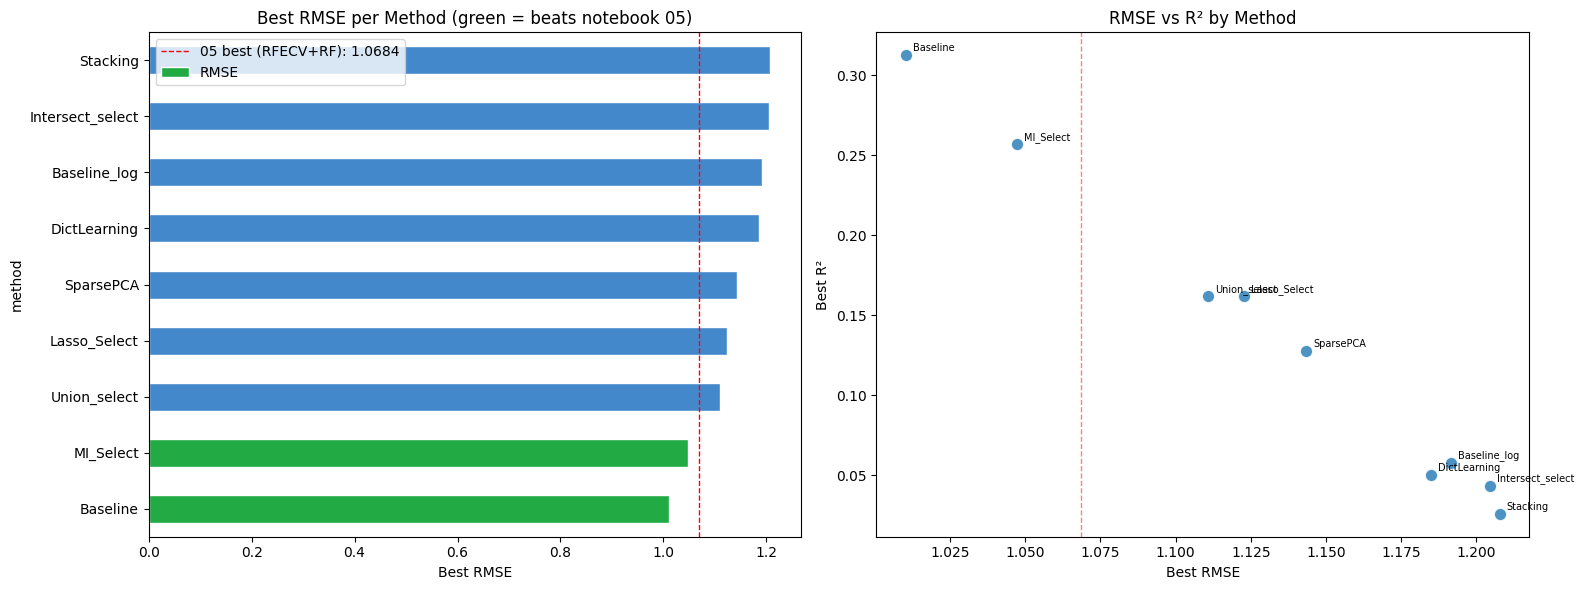

In [14]:
# ── Visualization ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: best RMSE per method
agg = results_df.groupby("method")["RMSE"].min().sort_values()
# Best from notebook 05: RFECV + RandomForest on fe_tabular
orig_best = 1.0684  # RFECV + RF from notebook 05_dimensionality_reduction
colors = ["#22aa44" if v < orig_best else "#4488cc" for v in agg.values]
agg.plot.barh(ax=axes[0], color=colors, edgecolor="white")
axes[0].axvline(orig_best, color="red", ls="--", lw=1, label=f"05 best (RFECV+RF): {orig_best:.4f}")
axes[0].set_xlabel("Best RMSE")
axes[0].set_title("Best RMSE per Method (green = beats notebook 05)")
axes[0].legend()

# Scatter: R² vs RMSE
scatter_df = results_df.groupby("method").agg({"RMSE": "min", "R2": "max"}).reset_index()
axes[1].scatter(scatter_df["RMSE"], scatter_df["R2"], s=80, alpha=0.8, edgecolors="white")
for _, row in scatter_df.iterrows():
    axes[1].annotate(row["method"], (row["RMSE"], row["R2"]), fontsize=7,
                     textcoords="offset points", xytext=(5, 3))
axes[1].set_xlabel("Best RMSE")
axes[1].set_ylabel("Best R²")
axes[1].set_title("RMSE vs R² by Method")
axes[1].axvline(orig_best, color="red", ls="--", lw=1, alpha=0.5)

plt.tight_layout()
plt.show()


In [15]:
# ── Save results to CSV ─────────────────────────────────────────────────────
from pathlib import Path

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

out_path = RESULTS_DIR / "05b_advanced_results.csv"
# Use results_df already built above
adv_df = pd.DataFrame(all_results).dropna(subset=["RMSE"])
adv_df = adv_df.sort_values("RMSE")
adv_df.to_csv(out_path, index=False)
print(f"Results saved to: {out_path.resolve()}")
print(f"  Shape: {adv_df.shape}")
print(adv_df[["method", "model", "dataset", "RMSE", "CV_RMSE", "MAE", "R2"]].head(10).to_string(index=False))


Results saved to: /home/aurorax/Git_repos/turbidity_satellite_estimation/results/05b_advanced_results.csv
  Shape: (103, 8)
      method model         dataset     RMSE  CV_RMSE      MAE       R2
    Baseline    RF   fe_64px_stats 1.010359 0.724759 0.645865 0.312629
   MI_Select    RF fe_64px_texture 1.047299 0.752530 0.680768 0.256871
    Baseline    RF      fe_tabular 1.061481 0.788708 0.642059 0.237501
   MI_Select    RF fe_64px_texture 1.093027 0.788366 0.693629 0.178657
   MI_Select    RF fe_64px_texture 1.098964 0.789491 0.698905 0.182613
Union_select    RF fe_64px_texture 1.110819 0.800285 0.690462 0.151061
   MI_Select    RF fe_64px_texture 1.115527 0.801734 0.698912 0.156426
    Baseline   KNN fe_64px_texture 1.118556 0.803261 0.716934 0.149615
Union_select    RF   fe_64px_stats 1.118798 0.801773 0.676911 0.161867
Lasso_Select    RF   fe_64px_stats 1.122805 0.802877 0.692322 0.161848
